In [ ]:
#Import Library
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import pandas as pd
import cv2
import random


In [ ]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#Path Dataset
DATASET_PATH = "/content/drive/MyDrive/Skripsi/Dataset/banana_classification"
TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VALID_DIR = os.path.join(DATASET_PATH, "valid")
TEST_DIR = os.path.join(DATASET_PATH, "test")


In [ ]:
#Hyperparameter
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 40


In [ ]:
# Data Augmentasi & Normalisasi
datagen_train = ImageDataGenerator(
    rescale=1./255,  # Normalisasi nilai pixel ke [0,1]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen_valid = ImageDataGenerator(rescale=1./255)
datagen_test = ImageDataGenerator(rescale=1./255)


In [ ]:


# Load Dataset
train_data = datagen_train.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_data = datagen_valid.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_data = datagen_test.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 11793 images belonging to 4 classes.
Found 1123 images belonging to 4 classes.
Found 562 images belonging to 4 classes.


In [ ]:
# Periksa Kelas yang Terdeteksi
print("Kelas yang terdeteksi:", train_data.class_indices)


Kelas yang terdeteksi: {'overripe': 0, 'ripe': 1, 'rotten': 2, 'unripe': 3}


In [ ]:
# print("bagian flow yang sudah terdefinisikan:")

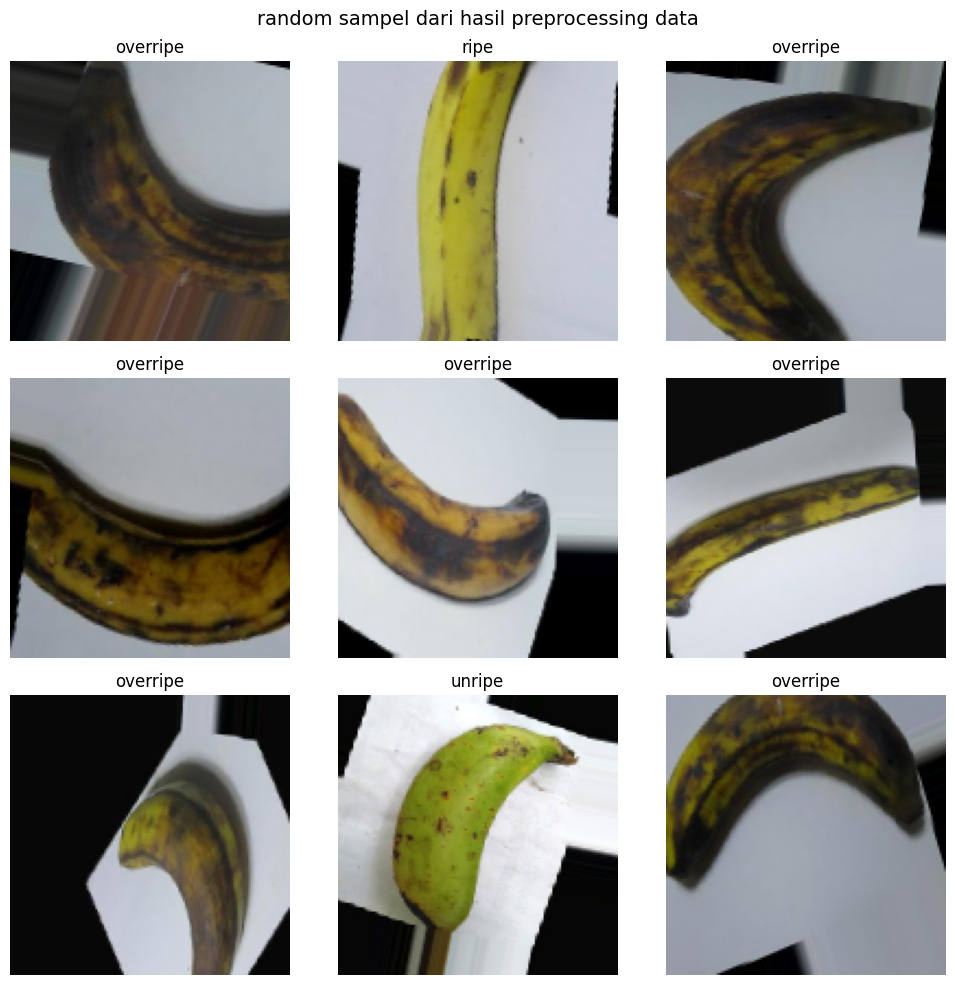

In [ ]:
# sampel gambar hasil preprocessing data
x_batch, y_batch = next(train_data)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    label_index = np.argmax(y_batch[i])
    label = list(train_data.class_indices.keys())[label_index]
    plt.title(label)
    plt.axis("off")
plt.suptitle("random sampel dari hasil preprocessing data", fontsize=14)
plt.tight_layout()
plt.show()

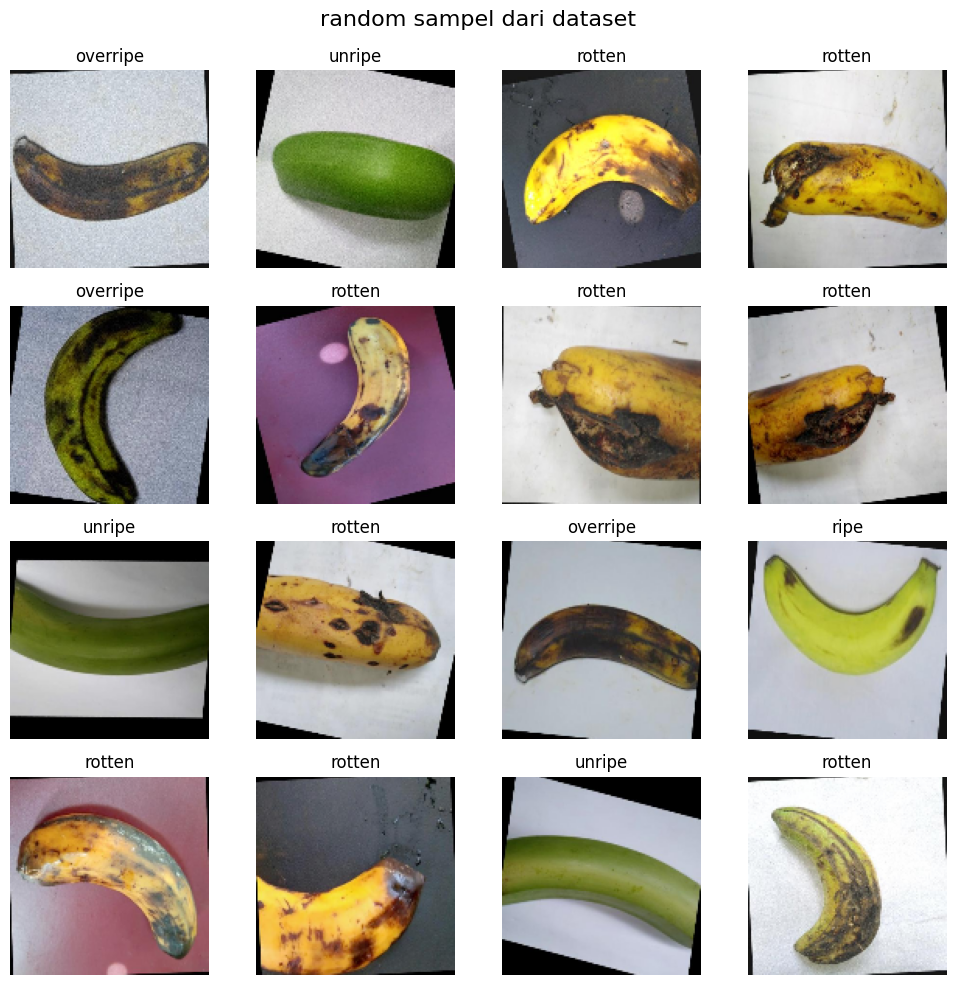

In [ ]:
# sampling gambar dataset
class_names = list(train_data.class_indices.keys())
all_image_paths = []
all_image_labels = []

for class_name in class_names:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    for fname in os.listdir(class_dir):
        fpath = os.path.join(class_dir, fname)
        if os.path.isfile(fpath):
            all_image_paths.append(fpath)
            all_image_labels.append(class_name)

random_indices = random.sample(range(len(all_image_paths)), 16)

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
fig.suptitle('random sampel dari dataset', fontsize=16)

for i, ax in enumerate(axes.flat):
    img_path = all_image_paths[random_indices[i]]
    label = all_image_labels[random_indices[i]]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)

    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


In [ ]:
# Rancangan Model CNN
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile Model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
#

In [ ]:
# Ringkasan Model
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5385 - loss: 1.0271

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


369/369 ━━━━━━━━━━━━━━━━━━━━ 4017s 11s/step - accuracy: 0.5388 - loss: 1.0263 - val_accuracy: 0.8388 - val_loss: 0.3638
Epoch 2/40
369/369 ━━━━━━━━━━━━━━━━━━━━ 498s 1s/step - accuracy: 0.8369 - loss: 0.4465 - val_accuracy: 0.8531 - val_loss: 0.4193
Epoch 3/40
369/369 ━━━━━━━━━━━━━━━━━━━━ 485s 1s/step - accuracy: 0.8608 - loss: 0.3765 - val_accuracy: 0.8753 - val_loss: 0.4181
Epoch 4/40
369/369 ━━━━━━━━━━━━━━━━━━━━ 513s 1s/step - accuracy: 0.8992 - loss: 0.2912 - val_accuracy: 0.9012 - val_loss: 0.3510
Epoch 5/40
369/369 ━━━━━━━━━━━━━━━━━━━━ 497s 1s/step - accuracy: 0.8999 - loss: 0.2868 - val_accuracy: 0.8744 - val_loss: 0.5446
Epoch 6/40
369/369 ━━━━━━━━━━━━━━━━━━━━ 486s 1s/step - accuracy: 0.9005 - loss: 0.2849 - val_accuracy: 0.9279 - val_loss: 0.1961
Epoch 7/40
369/369 ━━━━━━━━━━━━━━━━━━━━ 491s 1s/step - accuracy: 0.9061 - loss: 0.2805 - val_accuracy: 0.9270 - val_loss: 0.2050
Epoch 8/40
369/369 ━━━━━━━━━━━━━━━━━━━━ 484s 1s/step - accuracy: 0.9127 - loss: 0.2499 - val_accuracy: 0.9

In [ ]:
# Evaluasi Model
test_loss, test_acc = model.evaluate(test_data)
print(f"Akurasi Model pada Data Uji: {test_acc:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


18/18 ━━━━━━━━━━━━━━━━━━━━ 199s 12s/step - accuracy: 0.9525 - loss: 0.1512
Akurasi Model pada Data Uji: 0.9484


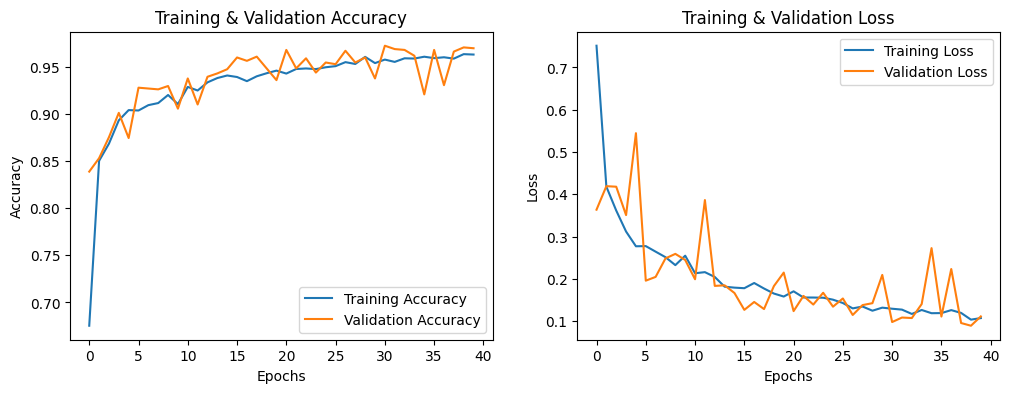

In [ ]:


# Visualisasi Akurasi & Loss
plt.figure(figsize=(12, 4))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.show()


Menguji 80 gambar (20 tiap kelas).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━

<Figure size 800x600 with 0 Axes>

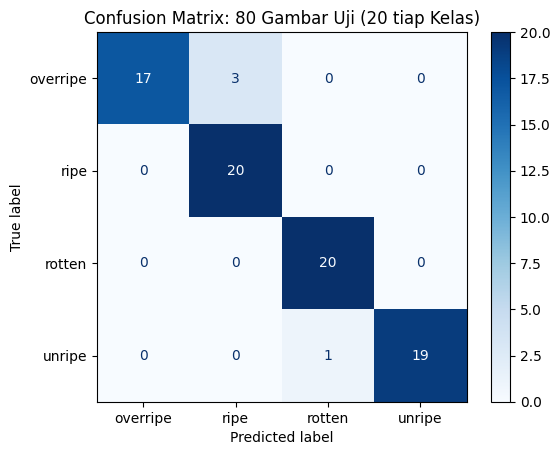

hasil Klasifikasi:

              precision    recall  f1-score   support

    overripe       1.00      0.85      0.92        20
        ripe       0.87      1.00      0.93        20
      rotten       0.95      1.00      0.98        20
      unripe       1.00      0.95      0.97        20

    accuracy                           0.95        80
   macro avg       0.96      0.95      0.95        80
weighted avg       0.96      0.95      0.95        80


sampel Hasil Prediksi:
                                                File True Label  \
0  /content/drive/MyDrive/Skripsi/Dataset/banana_...   overripe   
1  /content/drive/MyDrive/Skripsi/Dataset/banana_...   overripe   
2  /content/drive/MyDrive/Skripsi/Dataset/banana_...   overripe   
3  /content/drive/MyDrive/Skripsi/Dataset/banana_...   overripe   
4  /content/drive/MyDrive/Skripsi/Dataset/banana_...   overripe   
5  /content/drive/MyDrive/Skripsi/Dataset/banana_...   overripe   
6  /content/drive/MyDrive/Skripsi/Dataset/banana_...

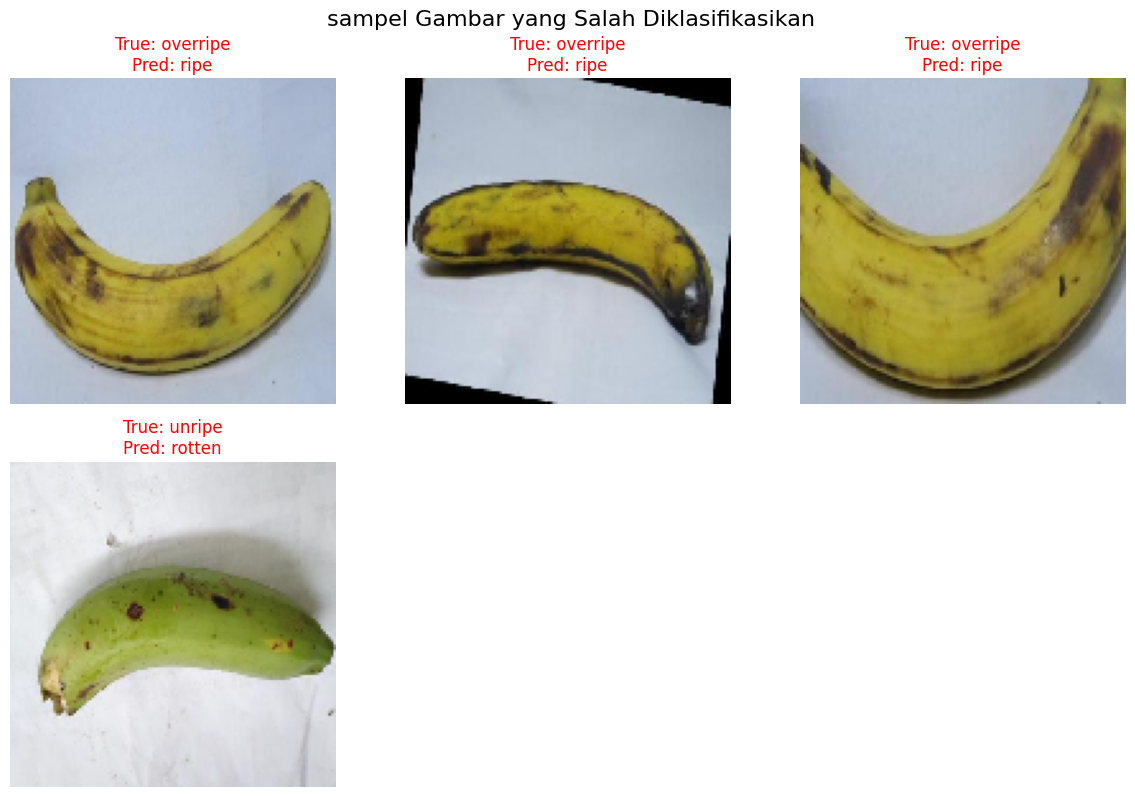

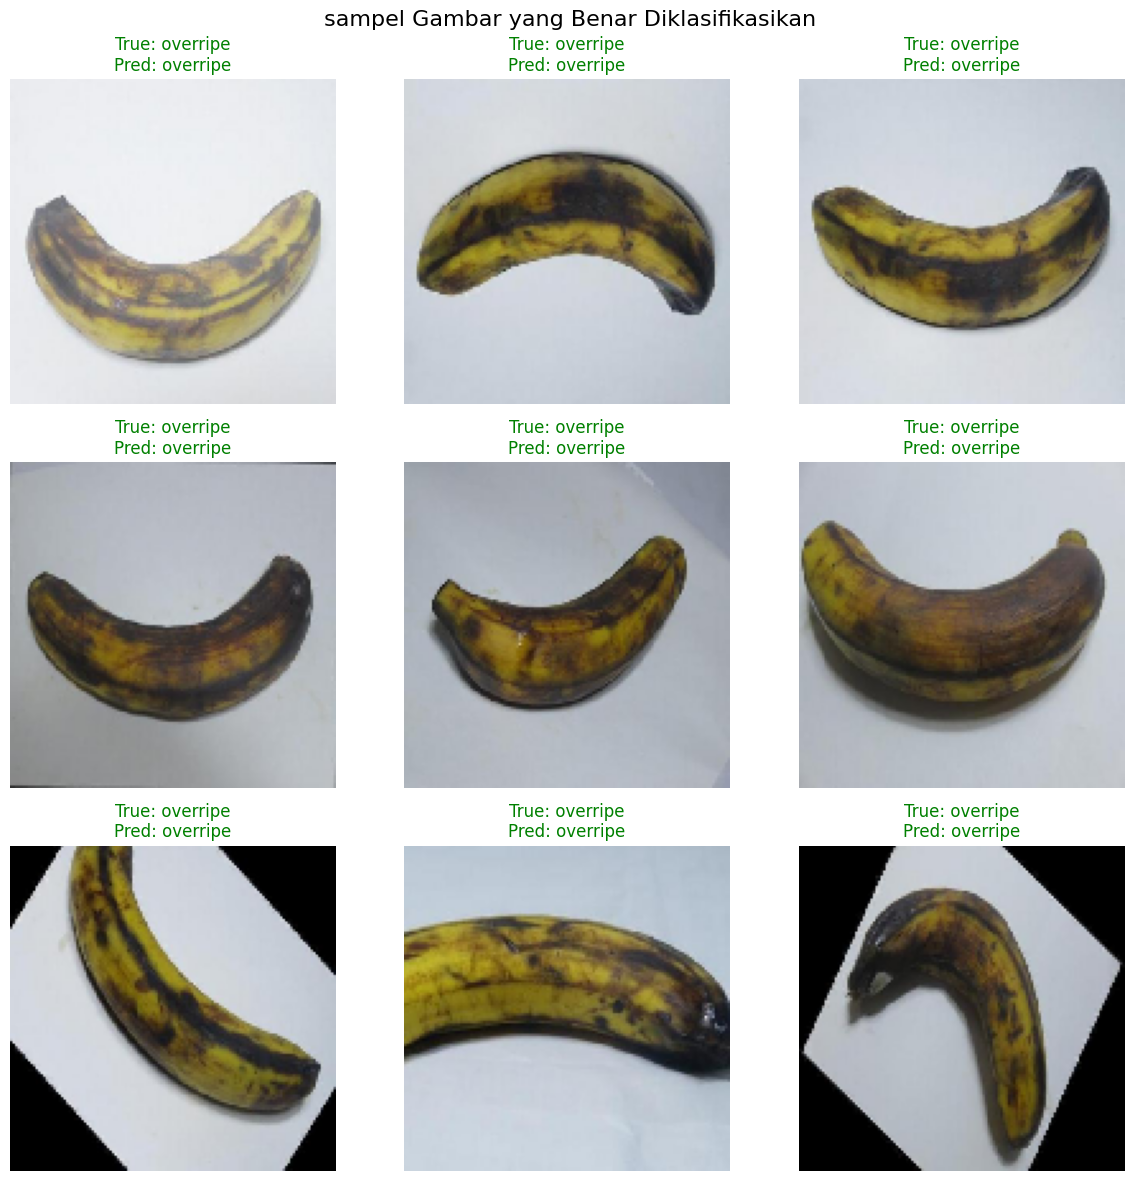

In [ ]:
# testing
print("\nMenguji 80 gambar (20 tiap kelas).")

# Ambil Gambar dan Label
test_image_paths = []
test_true_labels = []

for class_name in train_data.class_indices.keys():
    class_dir = os.path.join(TEST_DIR, class_name)
    image_files = os.listdir(class_dir)
    selected_files = np.random.choice(image_files, 20, replace=False)
    for fname in selected_files:
        fpath = os.path.join(class_dir, fname)
        test_image_paths.append(fpath)
        test_true_labels.append(class_name)

# Prediksi Gambar
test_pred_labels = []
for img_path in test_image_paths:
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    pred_label = list(train_data.class_indices.keys())[np.argmax(pred[0])]
    test_pred_labels.append(pred_label)

# Confusion Matrix dan Classification Report
label_names = list(train_data.class_indices.keys())
true_label_indices = [label_names.index(lbl) for lbl in test_true_labels]
pred_label_indices = [label_names.index(lbl) for lbl in test_pred_labels]

# Confusion Matrix
cm = confusion_matrix(true_label_indices, pred_label_indices)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix: 80 Gambar Uji (20 tiap Kelas)")
plt.show()

# Classification Report
report = classification_report(true_label_indices, pred_label_indices, target_names=label_names)
print("hasil Klasifikasi:\n")
print(report)

# Tabel Ringkasan
result_df = pd.DataFrame({
    'File': test_image_paths,
    'True Label': test_true_labels,
    'Predicted Label': test_pred_labels
})
print("\nsampel Hasil Prediksi:")
print(result_df.head(10))

# sampling gambar hasil testing
# Menentukan indeks yang salah dan benar diklasifikasikan
misclassified_indices = []
correct_indices = []

for i in range(len(test_true_labels)):
    if test_true_labels[i] != test_pred_labels[i]:
        misclassified_indices.append(i)
    else:
        correct_indices.append(i)

# Tampilkan gambar
def show_sample_images(indices, title, color='black', max_images=9):
    count = min(max_images, len(indices))
    if count == 0:
        print(f"Tidak ada gambar untuk ditampilkan dalam: {title}")
        return

    plt.figure(figsize=(12, 12))
    for i in range(count):
        idx = indices[i]
        img_path = test_image_paths[idx]
        img = image.load_img(img_path, target_size=IMG_SIZE)

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"True: {test_true_labels[idx]}\nPred: {test_pred_labels[idx]}", color=color)
        plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Tampilkan gambar yang salah diklasifikasikan
show_sample_images(
    misclassified_indices,
    title=" sampel Gambar yang Salah Diklasiﬁkasikan",
    color='red'
)

# Tampilkan gambar yang benar diklasifikasikan
show_sample_images(
    correct_indices,
    title=" sampel Gambar yang Benar Diklasiﬁkasikan",
    color='green'
)



Menampilkan hasil aktivasi (konvolusi) dari setiap layer Conv2D:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


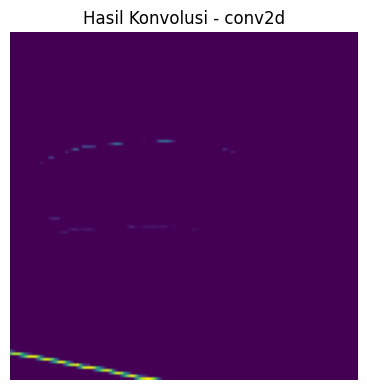

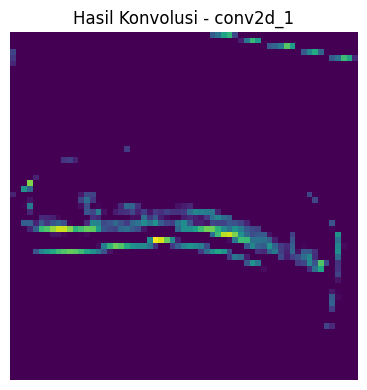

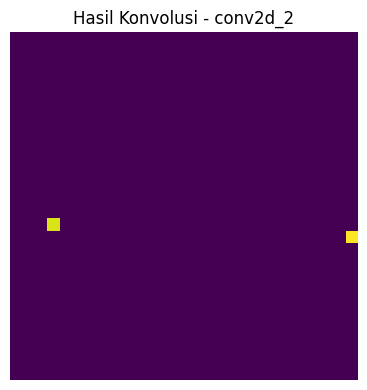

In [ ]:
# @title
  print("\nMenampilkan hasil aktivasi (konvolusi) dari setiap layer Conv2D:")

# Ambil Gambar dan Label (moved from the cell below)
test_image_paths = []
test_true_labels = []

for class_name in train_data.class_indices.keys():
    class_dir = os.path.join(TEST_DIR, class_name)
    image_files = os.listdir(class_dir)
    # Using all files in the test directory for visualization
    for fname in image_files:
        fpath = os.path.join(class_dir, fname)
        test_image_paths.append(fpath)
        test_true_labels.append(class_name)

# Pilih 1 gambar dari data uji
# Ensure there is at least one image path
if test_image_paths:
    sample_img_path = test_image_paths[0]
    img = image.load_img(sample_img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Ambil layer Conv2D
    conv_layers = [layer for layer in model.layers if isinstance(layer, layers.Conv2D)]
    layer_outputs = [layer.output for layer in conv_layers]

    # use input from the first layer of the model
    activation_model = keras.models.Model(inputs=model.layers[0].input, outputs=layer_outputs)

    # Hitung hasil aktivasi
    activations = activation_model.predict(img_array)
    layer_names = [layer.name for layer in conv_layers]

    # Visualisasi 1 filter dari tiap layer
    for layer_name, activation in zip(layer_names, activations):
        feature_map = activation[0, :, :, 0]  # ambil filter pertama
        plt.figure(figsize=(4, 4))
        plt.imshow(feature_map, cmap='viridis')
        plt.title(f'Hasil Konvolusi - {layer_name}')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print("No images found in the test directory.")
    #ini adalah hasil dari konvolusi layer ketiga